<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab4_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Wide MLPs on MNIST

In [2]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

# fix random seed
seed = 7
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import numpy as np
np.random.seed(seed)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

trainset = MNIST(".", train=True, download=True, transform=transform)
testset = MNIST(".", train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.98MB/s]


In [29]:
class BaselineModel(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(BaselineModel, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.fc1(x)
    out = F.relu(out)
    out = self.fc2(out)

    #if not self.training:
    #  out = F.softmax(out, dim=1)
    return out

def train(model: nn.Module, optimiser: optim.Optimizer, trainloader, num_epochs=10, device="cpu"):
  loss_function = nn.CrossEntropyLoss()
  train_loss_histroy = []
  test_loss_history = []

  train_accuracy_history = []
  test_accuracy_history = []

  for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for data in trainloader:
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)
      optimiser.zero_grad()
      outputs = model(inputs)
      loss = loss_function(outputs, labels)
      loss.backward()
      optimiser.step()

      running_loss += loss.item()

    running_loss = running_loss / len(trainloader)
    t_loss = test_loss(model)
    print("Epoch %d, train_loss %4.2f; test_loss  %4.2f" % (epoch, running_loss, t_loss))
    train_loss_histroy.append(running_loss)
    test_loss_history.append(test_loss(model))

    train_accuracy = accuracy(model, trainloader)
    train_accuracy_history.append(train_accuracy)
    test_accuracy = accuracy(model, testloader)
    test_accuracy_history.append(test_accuracy)
    print("Accuracy, Train: %4.2f, Test: %4.2f" % (train_accuracy, test_accuracy))

  print('**** Finished Training ****')
  return train_loss_histroy, test_loss_history, train_accuracy_history, test_accuracy_history

def test_loss(model: nn.Module):
  loss_function = nn.CrossEntropyLoss()
  running_loss = 0.0

  model.eval()

  with torch.no_grad():
    for data in testloader:
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = loss_function(outputs, labels)
      running_loss += loss.item()
  return running_loss / len(testloader)

def accuracy(model: nn.Module, target_data: DataLoader):
  model.eval()

  total = 0
  correct = 0

  with torch.no_grad():
    for data in target_data:
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)
      total += len(labels)
      output = model(inputs)
      predict = torch.argmax(output, dim=1)
      correct += (predict == labels).float().sum()

  return (correct / total).item()


In [30]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

hidden_layer_widths = [50, 500, 5000, 50000, 500000]

history_data = []

for hidden_layer_width in hidden_layer_widths:
  model = BaselineModel(784, hidden_layer_width, 10).to(device)
  optimiser = optim.Adam(model.parameters())

  print(f"Model: {hidden_layer_width}")
  history_data.append(train(model, optimiser, trainloader, device=device))



Model: 50
Epoch 0, train_loss 0.52; test_loss  0.27
Accuracy, Train: 0.92, Test: 0.92
Epoch 1, train_loss 0.25; test_loss  0.21
Accuracy, Train: 0.94, Test: 0.94
Epoch 2, train_loss 0.20; test_loss  0.18
Accuracy, Train: 0.95, Test: 0.95
Epoch 3, train_loss 0.17; test_loss  0.15
Accuracy, Train: 0.96, Test: 0.95
Epoch 4, train_loss 0.14; test_loss  0.14
Accuracy, Train: 0.96, Test: 0.96
Epoch 5, train_loss 0.12; test_loss  0.13
Accuracy, Train: 0.97, Test: 0.96
Epoch 6, train_loss 0.11; test_loss  0.12
Accuracy, Train: 0.97, Test: 0.96
Epoch 7, train_loss 0.10; test_loss  0.11
Accuracy, Train: 0.97, Test: 0.97
Epoch 8, train_loss 0.09; test_loss  0.11
Accuracy, Train: 0.98, Test: 0.97
Epoch 9, train_loss 0.08; test_loss  0.10
Accuracy, Train: 0.98, Test: 0.97
**** Finished Training ****
Model: 500
Epoch 0, train_loss 0.31; test_loss  0.15
Accuracy, Train: 0.96, Test: 0.95
Epoch 1, train_loss 0.13; test_loss  0.11
Accuracy, Train: 0.97, Test: 0.97
Epoch 2, train_loss 0.08; test_loss  0.

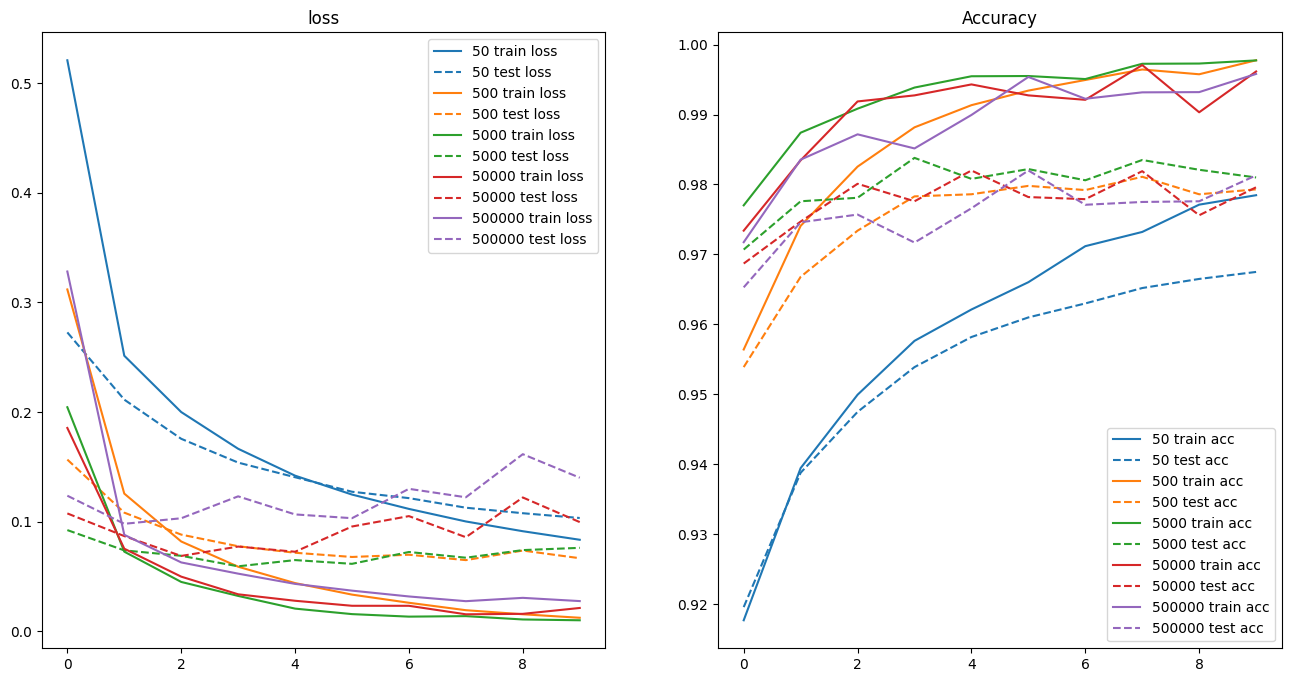

In [39]:
import matplotlib.pyplot as plt

fix, axs = plt.subplots(1, 2, figsize=(16, 8))

xs = range(10)
i = 1
for (train_loss_histroy, test_loss_history, train_accuracy_history, test_accuracy_history) in history_data:
  model_title = f"{5*10**i}"
  p = axs[0].plot(xs, train_loss_histroy, label=f"{model_title} train loss", linestyle='-')
  axs[0].plot(xs, test_loss_history, label=f"{model_title} test loss", linestyle='--', color=p[0].get_color())
  axs[0].set_title("loss")
  axs[0].legend()

  axs[1].plot(xs, train_accuracy_history, label=f"{model_title} train acc", linestyle='-', color=p[0].get_color())
  axs[1].plot(xs, test_accuracy_history, label=f"{model_title} test acc", linestyle='--', color=p[0].get_color())
  axs[1].set_title("Accuracy")
  axs[1].legend()
  i+=1

Reduce the trainding dataset size to let it overfit

In [34]:
from torch.utils.data import Subset

device = "cuda:0" if torch.cuda.is_available() else "cpu"

subset_indices = np.random.choice(len(trainset), 500, replace=False)
subset = Subset(trainset, subset_indices)
trainloader_small = DataLoader(subset, batch_size=128, shuffle=True)

hidden_layer_widths = [50, 500, 5000, 50000, 500000]
history_data_2 = []

for hidden_layer_width in hidden_layer_widths:
  model = BaselineModel(784, hidden_layer_width, 10).to(device)
  optimiser = optim.Adam(model.parameters())

  print(f"Model: {hidden_layer_width}")
  history_data_2.append(train(model, optimiser, trainloader_small, device=device, num_epochs=10))

Model: 50
Epoch 0, train_loss 2.27; test_loss  2.19
Accuracy, Train: 0.46, Test: 0.43
Epoch 1, train_loss 2.13; test_loss  2.05
Accuracy, Train: 0.58, Test: 0.56
Epoch 2, train_loss 1.98; test_loss  1.91
Accuracy, Train: 0.65, Test: 0.62
Epoch 3, train_loss 1.83; test_loss  1.77
Accuracy, Train: 0.69, Test: 0.65
Epoch 4, train_loss 1.67; test_loss  1.62
Accuracy, Train: 0.75, Test: 0.70
Epoch 5, train_loss 1.51; test_loss  1.47
Accuracy, Train: 0.79, Test: 0.74
Epoch 6, train_loss 1.37; test_loss  1.34
Accuracy, Train: 0.82, Test: 0.77
Epoch 7, train_loss 1.22; test_loss  1.22
Accuracy, Train: 0.83, Test: 0.78
Epoch 8, train_loss 1.10; test_loss  1.11
Accuracy, Train: 0.84, Test: 0.79
Epoch 9, train_loss 0.99; test_loss  1.01
Accuracy, Train: 0.86, Test: 0.80
**** Finished Training ****
Model: 500
Epoch 0, train_loss 2.19; test_loss  1.93
Accuracy, Train: 0.71, Test: 0.66
Epoch 1, train_loss 1.74; test_loss  1.52
Accuracy, Train: 0.80, Test: 0.75
Epoch 2, train_loss 1.31; test_loss  1.

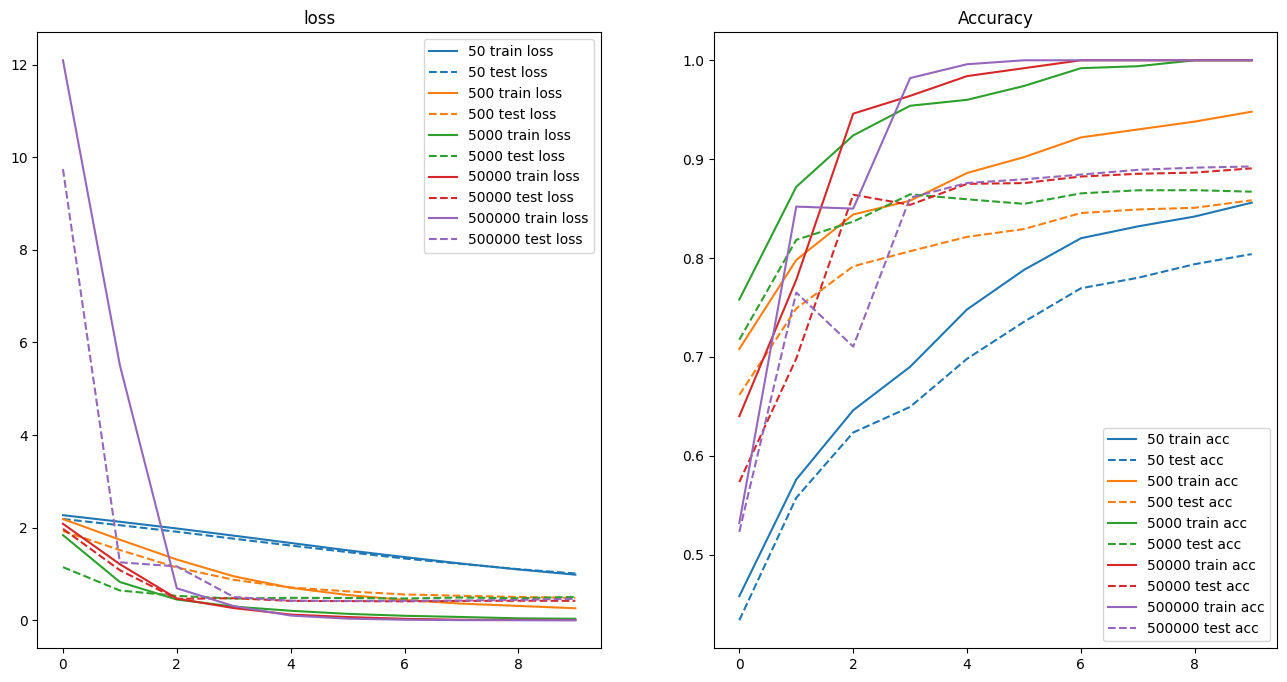

In [38]:
import matplotlib.pyplot as plt

fix, axs = plt.subplots(1, 2, figsize=(16, 8))

xs = range(10)
i = 1
for (train_loss_histroy, test_loss_history, train_accuracy_history, test_accuracy_history) in history_data_2:
  model_title = f"{5*10**i}"
  p = axs[0].plot(xs, train_loss_histroy, label=f"{model_title} train loss", linestyle='-')
  axs[0].plot(xs, test_loss_history, label=f"{model_title} test loss", linestyle='--', color=p[0].get_color())
  axs[0].set_title("loss")
  axs[0].legend()

  axs[1].plot(xs, train_accuracy_history, label=f"{model_title} train acc", linestyle='-', color=p[0].get_color())
  axs[1].plot(xs, test_accuracy_history, label=f"{model_title} test acc", linestyle='--', color=p[0].get_color())
  axs[1].set_title("Accuracy")
  axs[1].legend()
  i+=1